1. Given a small dataset of 6 food delivery orders (with features like delivery_time and distance), manually create the initial distance matrix using the Euclidean distance formula between each pair of orders.<br><br><em><strong>Hint:</strong> Use the formula sqrt((x2 - x1)^2 + (y2 - y1)^2) for each pair.</em>


In [1]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import pdist, squareform

orders = np.array([
    [20, 3],
    [25, 5],
    [18, 2],
    [40,10],
    [35, 8],
    [22, 4]
])

distance_matrix = squareform(pdist(orders, metric="euclidean"))

df = pd.DataFrame(
    distance_matrix,
    columns=["O1","O2","O3","O4","O5","O6"],
    index=["O1","O2","O3","O4","O5","O6"]
)

print(df.round(2))

       O1     O2     O3     O4     O5     O6
O1   0.00   5.39   2.24  21.19  15.81   2.24
O2   5.39   0.00   7.62  15.81  10.44   3.16
O3   2.24   7.62   0.00  23.41  18.03   4.47
O4  21.19  15.81  23.41   0.00   5.39  18.97
O5  15.81  10.44  18.03   5.39   0.00  13.60
O6   2.24   3.16   4.47  18.97  13.60   0.00


2. Using Python and sklearn, perform agglomerative hierarchical clustering on a dataset of 8 songs (with features like tempo and energy), and plot the resulting dendrogram using scipy's dendrogram function.

In [2]:
import pandas as pd

songs = pd.DataFrame({
    "tempo":[80,85,90,120,125,130,70,75],
    "energy":[0.30,0.35,0.40,0.85,0.90,0.95,0.25,0.20]
})

print(songs)

   tempo  energy
0     80    0.30
1     85    0.35
2     90    0.40
3    120    0.85
4    125    0.90
5    130    0.95
6     70    0.25
7     75    0.20


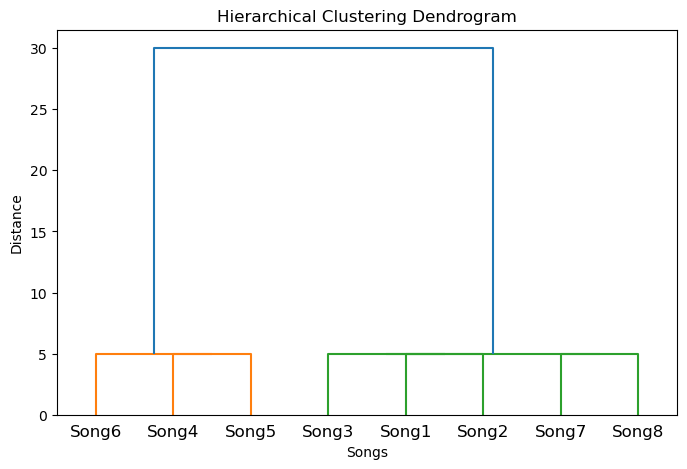

In [3]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

Z = linkage(songs, method="single")

plt.figure(figsize=(8,5))

dendrogram(
    Z,
    labels=[f"Song{i+1}" for i in range(len(songs))]
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Songs")
plt.ylabel("Distance")

plt.show()

3. Change the linkage method in your clustering code from 'single' to 'complete' and 'average', and observe how the dendrogram structure changes for your songs dataset.<br><br><em><strong>Hint:</strong> Use the linkage parameter in AgglomerativeClustering or scipy's linkage function.</em>

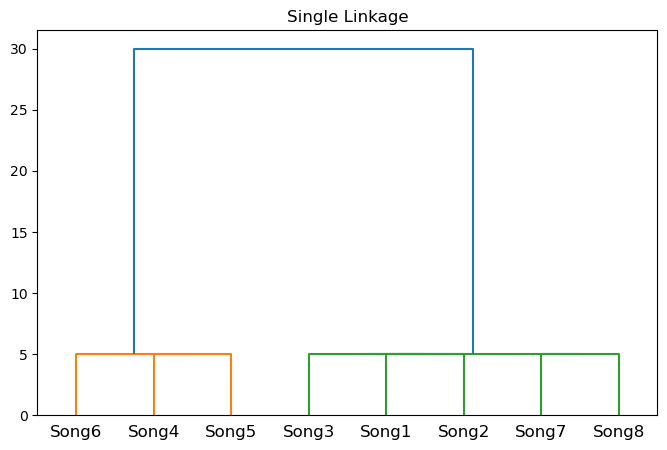

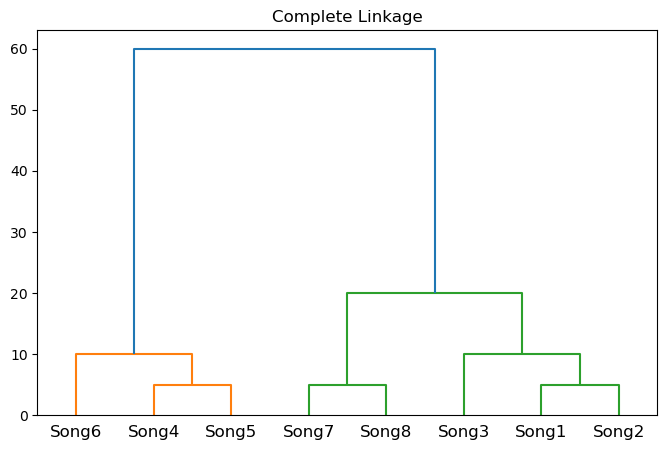

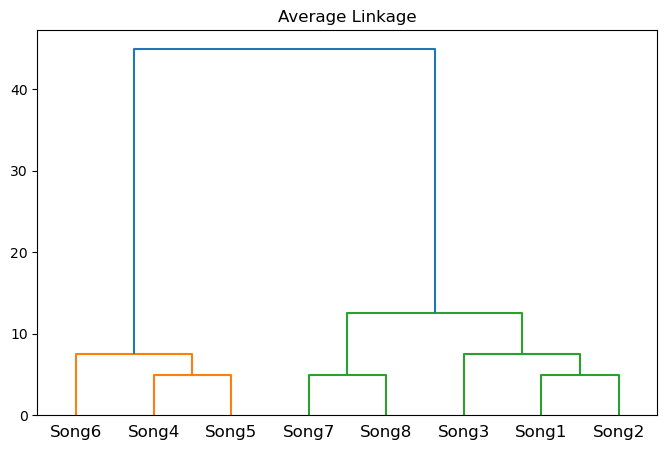

In [4]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

methods = ["single", "complete", "average"]

for method in methods:

    plt.figure(figsize=(8,5))

    Z = linkage(
        songs,
        method=method
    )

    dendrogram(
        Z,
        labels=[f"Song{i+1}" for i in range(len(songs))]
    )

    plt.title(f"{method.capitalize()} Linkage")

    plt.show()

4. Write a function that, given two points (x1, y1) and (x2, y2), returns both their Euclidean and Manhattan distances. Test it on three pairs of coordinates from your dataset.


In [5]:
import math

def calculate_distances(x1, y1, x2, y2):

    euclidean = math.sqrt(
        (x2 - x1)**2 +
        (y2 - y1)**2
    )

    manhattan = (
        abs(x2 - x1) +
        abs(y2 - y1)
    )

    return euclidean, manhattan

In [6]:
pairs = [

    ((20,3),(25,5)),
    ((18,2),(40,10)),
    ((35,8),(22,4))

]

for p1, p2 in pairs:

    e, m = calculate_distances(
        p1[0], p1[1],
        p2[0], p2[1]
    )

    print(f"{p1} -> {p2}")
    print("Euclidean:", round(e,2))
    print("Manhattan:", m)
    print()

(20, 3) -> (25, 5)
Euclidean: 5.39
Manhattan: 7

(18, 2) -> (40, 10)
Euclidean: 23.41
Manhattan: 30

(35, 8) -> (22, 4)
Euclidean: 13.6
Manhattan: 17



5. Imagine you are building a 'similar movies' feature for a movie app. Briefly describe which linkage method (single, complete, average, or Ward) you would choose for grouping movies by user ratings and why.

If building a similar movies feature based on user ratings, I would choose Ward Linkage.

Why Ward Linkage?
It minimizes the variance within each cluster.
Movies in the same cluster tend to have very similar rating patterns.
It usually produces balanced and meaningful clusters.
It avoids the chaining effect often seen in Single Linkage.
Example

A Ward-based clustering system might group:

Action movies together
Romantic movies together
Sci-fi movies together

based on how users rate them, making recommendations more accurate and consistent.